In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# Country Segmentation using Unsupervised Learning

## Project Objective

The objective of this project is to categorize countries based on socio-economic and health indicators using clustering techniques. The analysis aims to identify countries that require the highest priority for humanitarian aid and development support.

## Import Required Libraries

Import the libraries required for data preprocessing, visualization, clustering, dimensionality reduction, and machine learning analysis.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [8]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


## Loading Dataset

Load the country-level socio-economic and health dataset into the notebook for analysis.

In [9]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
)

print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [10]:
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


## Data Cleaning and Preprocessing

Clean the dataset by removing duplicates, converting features to numeric format, handling missing values, and preparing the data for clustering.

In [11]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows:
0


In [12]:
df.columns = df.columns.str.strip()

df.drop_duplicates(inplace=True)

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [13]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Correlation Analysis

Analyze relationships between socio-economic and health indicators using a correlation heatmap.

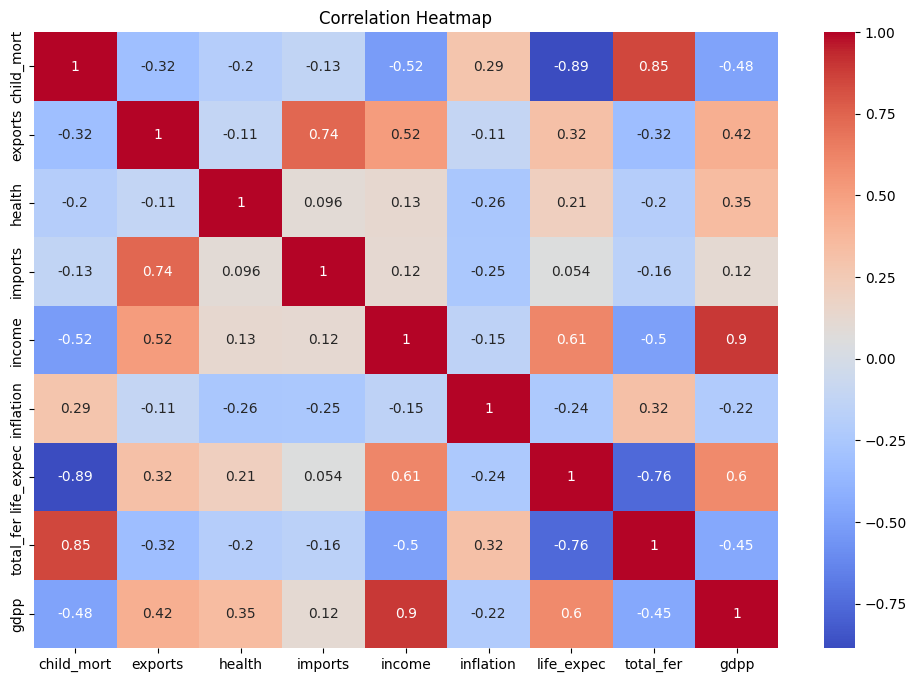

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop('country',axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
country_names = df['country']

features = df.drop('country', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

print("Feature Matrix Shape:", X_scaled.shape)
print("Features Used:", list(features.columns))

Feature Matrix Shape: (167, 9)
Features Used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## Income Distribution

Visualize the distribution of income across countries.

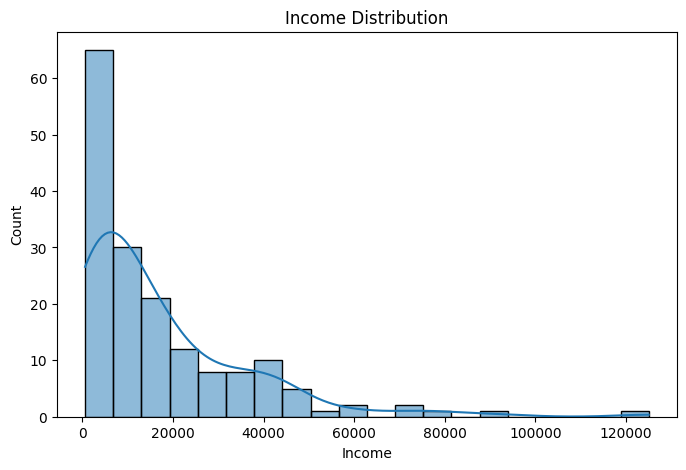

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['income'],
    bins=20,
    kde=True
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

## Child Mortality Distribution

Examine the distribution of child mortality rates among countries.

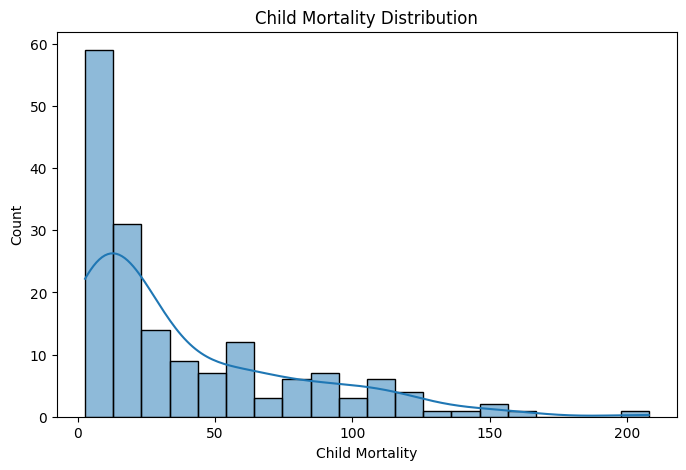

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['child_mort'],
    bins=20,
    kde=True
)

plt.title("Child Mortality Distribution")
plt.xlabel("Child Mortality")
plt.ylabel("Count")

plt.show()

## GDP Distribution

Visualize the distribution of GDP per capita across countries.

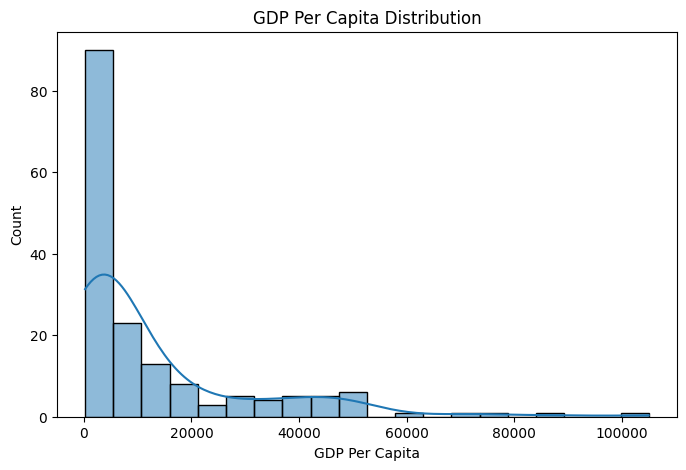

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['gdpp'],
    bins=20,
    kde=True
)

plt.title("GDP Per Capita Distribution")
plt.xlabel("GDP Per Capita")
plt.ylabel("Count")

plt.show()

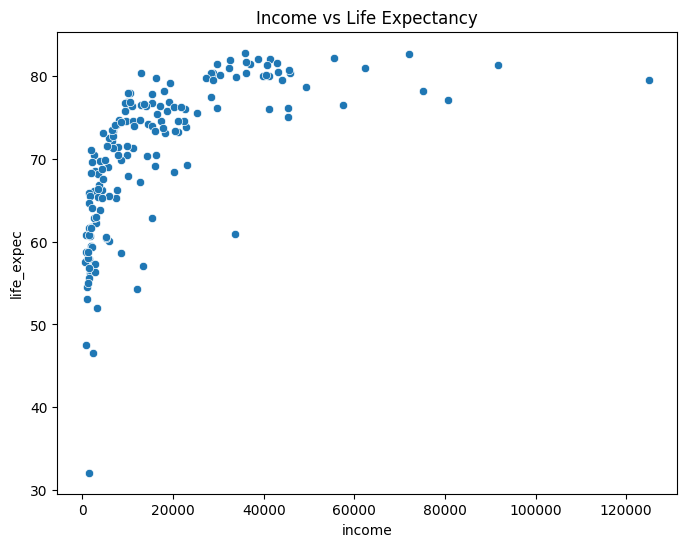

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='income',
    y='life_expec',
    data=df
)

plt.title("Income vs Life Expectancy")

plt.show()

In [20]:
countries = df['country']

X = df.drop('country', axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Feature Selection and Standardization

Remove the country identifier column and standardize numerical features using StandardScaler to ensure equal contribution during clustering.

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


## Elbow Method

Determine the optimal number of clusters by evaluating inertia values across different values of k.

In [22]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:.2f}")

k=2: inertia=1050.21
k=3: inertia=831.42
k=4: inertia=700.52
k=5: inertia=620.16
k=6: inertia=558.47
k=7: inertia=495.81
k=8: inertia=457.59
k=9: inertia=427.80
k=10: inertia=403.23


## Elbow Curve Visualization

Plot the inertia values obtained from K-Means clustering to identify the optimal cluster count.

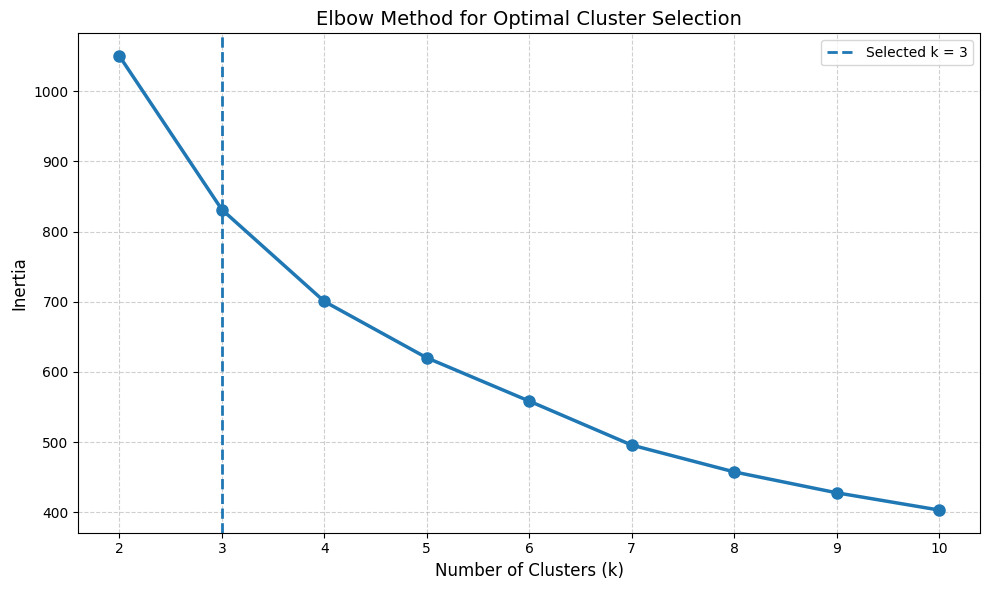

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    list(k_range),
    inertia_values,
    marker='o',
    linewidth=2.5,
    markersize=8
)

ax.axvline(
    x=3,
    linestyle='--',
    linewidth=2,
    label='Selected k = 3'
)

ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method for Optimal Cluster Selection', fontsize=14)

ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## K-Means Clustering

Apply K-Means clustering with the selected number of clusters (k = 3) to segment countries based on socio-economic characteristics.

In [24]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(f"K-Means trained with k={best_k}")

print("Cluster distribution:")

for c, count in pd.Series(clusters).value_counts().sort_index().items():
    print(f"Cluster {c}: {count} countries")

K-Means trained with k=3
Cluster distribution:
Cluster 0: 36 countries
Cluster 1: 47 countries
Cluster 2: 84 countries


## Silhouette Score Evaluation

Evaluate clustering performance using the Silhouette Score to measure cluster cohesion and separation.

In [25]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", round(score,4))

Silhouette Score: 0.2833


## DBSCAN Clustering

Apply Density-Based Spatial Clustering of Applications with Noise (DBSCAN) to identify clusters and outliers in the dataset.

In [26]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("Clusters found:", n_clusters_db)
print("Noise points:", n_noise)

print("\nCluster Distribution:")

for c, count in pd.Series(dbscan_labels).value_counts().sort_index().items():

    label = "Noise" if c == -1 else f"Cluster {c}"

    print(f"{label}: {count} countries")

Clusters found: 1
Noise points: 30

Cluster Distribution:
Noise: 30 countries
Cluster 0: 137 countries


## Principal Component Analysis (PCA)

Reduce the dimensionality of the dataset to two principal components for visualization purposes.

In [27]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

print(f"PC1 Variance Explained: {explained_var[0]*100:.2f}%")
print(f"PC2 Variance Explained: {explained_var[1]*100:.2f}%")
print(f"Total Variance Explained: {sum(explained_var)*100:.2f}%")

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = clusters

PC1 Variance Explained: 45.95%
PC2 Variance Explained: 17.18%
Total Variance Explained: 63.13%


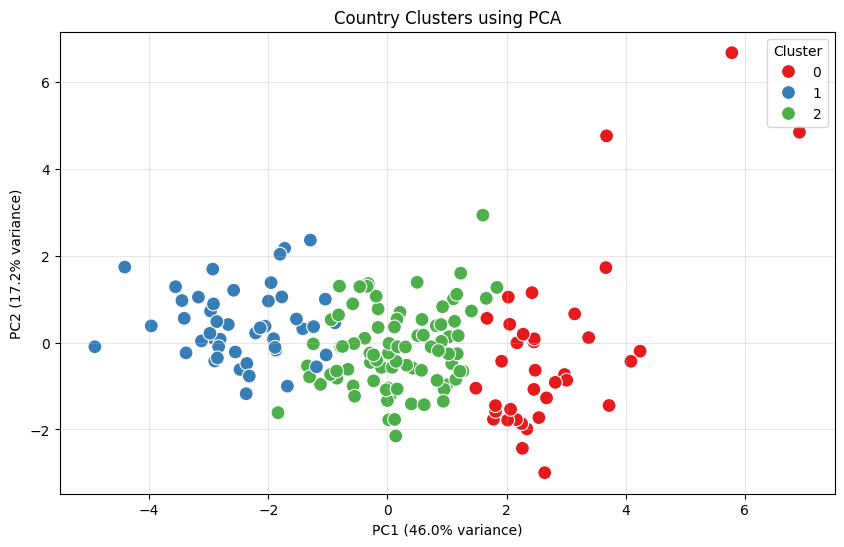

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_df,
    s=100
)

plt.title("Country Clusters using PCA")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")

plt.grid(True, alpha=0.3)

plt.show()

In [29]:
cluster_summary = df.groupby(
    'Cluster'
).mean(
    numeric_only=True
)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


## Cluster Summary Statistics

Calculate average socio-economic and health indicators for each cluster to understand cluster characteristics.

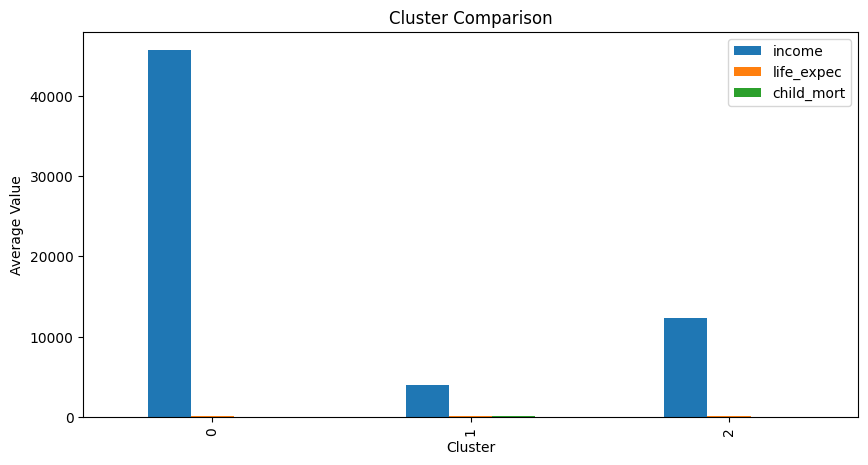

In [30]:
cluster_summary[
    ['income',
     'life_expec',
     'child_mort']
].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Cluster Comparison")
plt.ylabel("Average Value")

plt.show()

In [31]:
for i in range(best_k):

    print("\nCluster", i)

    print(
        df[
            df['Cluster'] == i
        ]['country'].tolist()
    )


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'To

In [32]:
aid_cluster = cluster_summary['income'].idxmin()

print("Cluster Needing Most Aid:", aid_cluster)

df[
    df['Cluster'] == aid_cluster
][
    ['country',
     'income',
     'child_mort',
     'life_expec']
].sort_values(
    by='child_mort',
    ascending=False
).head(10)

Cluster Needing Most Aid: 1


,country,income,child_mort,life_expec
66,Haiti,1500,208.0,32.1
132,Sierra Leone,1220,160.0,55.0
32,Chad,1930,150.0,56.5
31,Central African Republic,888,149.0,47.5
97,Mali,1870,137.0,59.5
113,Nigeria,5150,130.0,60.5
112,Niger,814,123.0,58.8
3,Angola,5900,119.0,60.1
25,Burkina Faso,1430,116.0,57.9
37,"Congo, Dem. Rep.",609,116.0,57.5


## Socio-Economic Observations

1. Cluster 1 represents underdeveloped countries with the lowest average income levels and relatively high child mortality rates. These countries require the highest priority for humanitarian assistance.

2. Cluster 0 represents highly developed economies with the highest average income, better healthcare outcomes, and higher life expectancy.

3. Cluster 2 consists of developing countries that fall between the developed and underdeveloped groups in terms of socio-economic indicators.

4. The PCA visualization shows reasonable separation among the three clusters, indicating that socio-economic and health factors effectively differentiate countries based on their level of development.

5. Based on the clustering results, HELP International should focus its resources on countries belonging to Cluster 1, as they exhibit the strongest indicators of economic hardship and developmental challenges.

# Additional Classification and Ensemble Learning Analysis

To further analyze the clustered countries, Random Forest and XGBoost are trained to predict cluster membership based on socio-economic indicators.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = features
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9761904761904762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.92      1.00      0.96        12
           2       1.00      0.95      0.98        21

    accuracy                           0.98        42
   macro avg       0.97      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9761904761904762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.92      0.96        12
           2       0.95      1.00      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



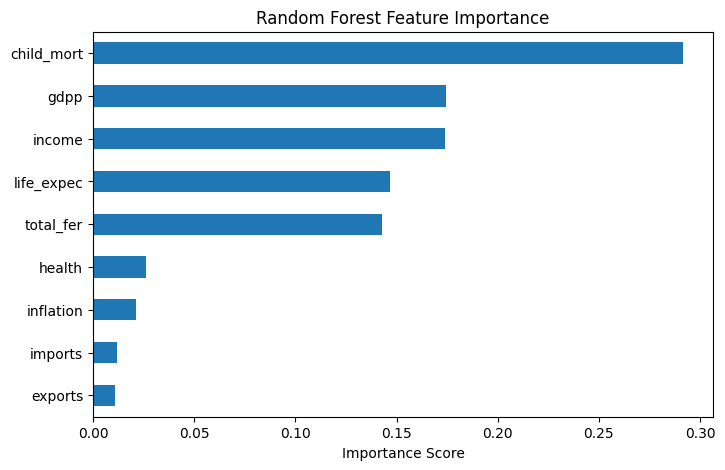

In [35]:
importance = pd.Series(
    rf.feature_importances_,
    index=features.columns
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind='barh')

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.show()